In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats

np.random.seed(42)

In [2]:
df = pd.DataFrame({
    "Employee_ID": range(1001, 1061),
    "Age": np.random.randint(22, 58, 60),
    "Experience": np.random.randint(1, 35, 60),
    "Salary": np.random.normal(70000, 18000, 60).astype(int),
    "Department": np.random.choice(
        ["IT", "HR", "Finance", "Sales"],
        60
    ),
    "Performance": np.random.randint(1, 6, 60),
    "Work_Hours": np.random.normal(44, 4, 60).round(1)
})

df.head()

,Employee_ID,Age,Experience,Salary,Department,Performance,Work_Hours
0,1001,50,23,43316,HR,3,45.4
1,1002,36,21,65880,Finance,5,46.2
2,1003,29,16,87327,Finance,1,48.3
3,1004,42,18,66225,HR,4,48.2
4,1005,40,24,56067,HR,1,38.5


In [4]:
df.shape

(60, 7)

# Numerical Analysis

In [6]:
df.describe()

,Employee_ID,Age,Experience,Salary,Performance,Work_Hours
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,38.616667,17.350000,69820.450000,3.050000,44.676667
std,17.464249,10.247929,10.080733,17836.040992,1.466288,4.400207
min,1001.000000,23.000000,1.000000,35081.000000,1.000000,35.900000
25%,1015.750000,29.750000,8.000000,56843.500000,2.000000,41.400000
50%,1030.500000,38.500000,16.500000,67472.500000,3.000000,45.150000
75%,1045.250000,46.250000,26.000000,83328.250000,4.000000,47.175000
max,1060.000000,57.000000,34.000000,122985.000000,5.000000,59.400000


In [9]:
df.dtypes

Employee_ID      int64
Age              int32
Experience       int32
Salary           int64
Department         str
Performance      int32
Work_Hours     float64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  60 non-null     int64  
 1   Age          60 non-null     int32  
 2   Experience   60 non-null     int32  
 3   Salary       60 non-null     int64  
 4   Department   60 non-null     str    
 5   Performance  60 non-null     int32  
 6   Work_Hours   60 non-null     float64
dtypes: float64(1), int32(3), int64(2), str(1)
memory usage: 2.7 KB


In [11]:
df.head()

,Employee_ID,Age,Experience,Salary,Department,Performance,Work_Hours
0,1001,50,23,43316,HR,3,45.4
1,1002,36,21,65880,Finance,5,46.2
2,1003,29,16,87327,Finance,1,48.3
3,1004,42,18,66225,HR,4,48.2
4,1005,40,24,56067,HR,1,38.5


In [14]:
df["Age"].mode() # 2 Values share the highest frequency

0    23
1    35
Name: Age, dtype: int32

In [15]:
print(df["Experience"].mode())
print(df["Salary"].mode())
print(df["Performance"].mode())
print(df["Work_Hours"].mode())

0     1
1    15
2    24
Name: Experience, dtype: int32
0      35081
1      43316
2      43746
3      44323
4      46206
5      46396
6      46420
7      48452
8      50258
9      50267
10     54334
11     54771
12     55195
13     56067
14     56272
15     57034
16     57718
17     57971
18     58010
19     58070
20     60751
21     60880
22     62048
23     63523
24     65141
25     65396
26     65880
27     66225
28     67363
29     67417
30     67528
31     68485
32     69182
33     70505
34     71181
35     73035
36     73904
37     75423
38     76084
39     77766
40     79223
41     79782
42     80898
43     81106
44     83033
45     84214
46     85298
47     85719
48     85975
49     86467
50     87327
51     88089
52     89561
53     91045
54     92266
55     92480
56     95223
57    105370
58    105542
59    122985
Name: Salary, dtype: int64
0    1
1    3
Name: Performance, dtype: int32
0    42.1
Name: Work_Hours, dtype: float64


In [16]:
df.head()

,Employee_ID,Age,Experience,Salary,Department,Performance,Work_Hours
0,1001,50,23,43316,HR,3,45.4
1,1002,36,21,65880,Finance,5,46.2
2,1003,29,16,87327,Finance,1,48.3
3,1004,42,18,66225,HR,4,48.2
4,1005,40,24,56067,HR,1,38.5


In [18]:
q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)
iqr = q3 - q1
lower = q1 - (1.5 * iqr)
higher = q3 + (1.5 * iqr)

print(f"{lower}, {higher}")

17116.375, 123055.375


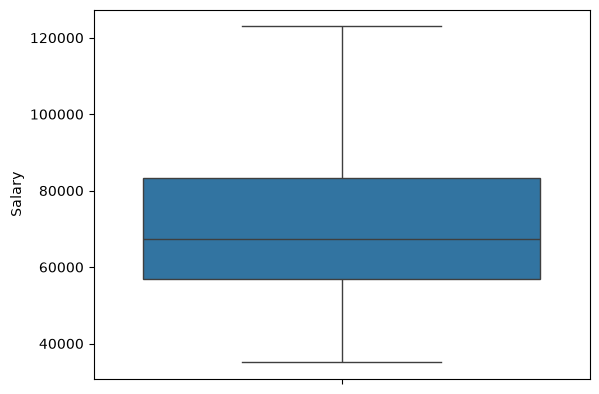

In [19]:
sns.boxplot(
    df["Salary"],
)
plt.show()

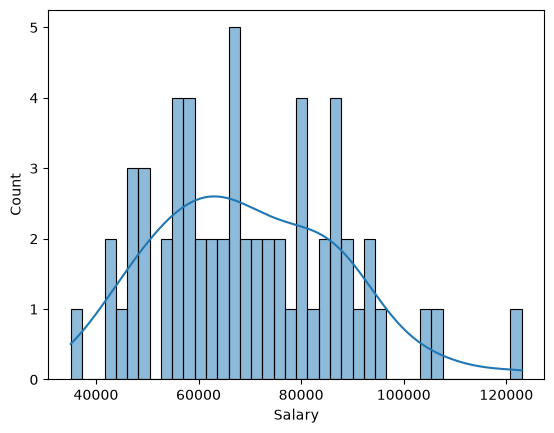

In [21]:
sns.histplot(
    df["Salary"],
    bins = 40,
    kde = True
)

plt.show()

# Categorical

In [22]:
df["Department"].value_counts()

Department
Sales      21
HR         15
Finance    12
IT         12
Name: count, dtype: int64

In [23]:
df.corr(numeric_only = True)

,Employee_ID,Age,Experience,Salary,Performance,Work_Hours
Employee_ID,1.000000,-0.034519,0.004188,0.189059,-0.074461,-0.097686
Age,-0.034519,1.000000,0.055791,-0.115160,-0.163385,0.055202
Experience,0.004188,0.055791,1.000000,0.196900,-0.034457,-0.149101
Salary,0.189059,-0.115160,0.196900,1.000000,0.058023,-0.015072
Performance,-0.074461,-0.163385,-0.034457,0.058023,1.000000,0.166734
Work_Hours,-0.097686,0.055202,-0.149101,-0.015072,0.166734,1.000000


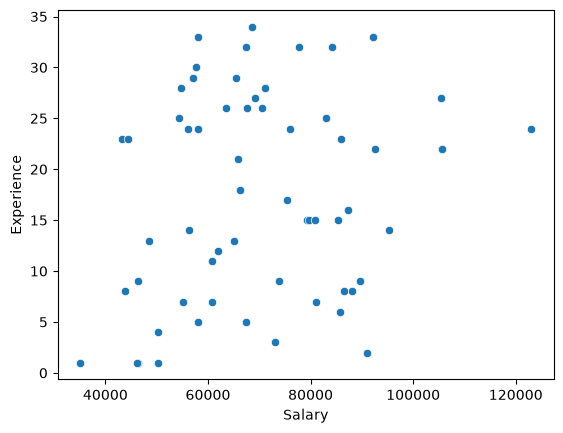

In [24]:
sns.scatterplot(
    x = df["Salary"],
    y = df["Experience"]
)
plt.show()

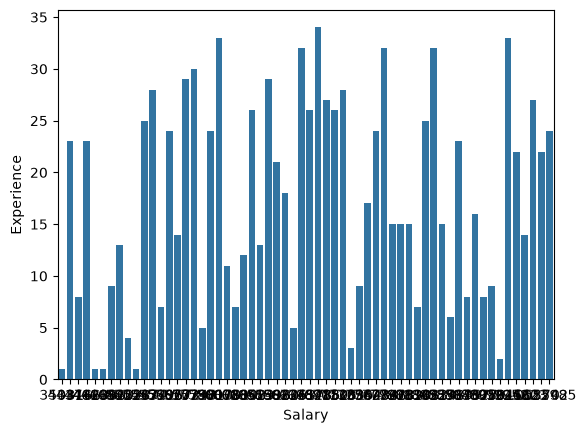

In [25]:
sns.barplot(
    x = df["Salary"],
    y = df["Experience"]
)

plt.show()

In [26]:
# df.groupby()

In [34]:
pd.crosstab(
    df["Department"],
    df["Experience"]
)

Experience,1,2,3,4,5,6,7,8,9,11,...,24,25,26,27,28,29,30,32,33,34
Department,,,,,,,,,,,,,,,,,,,,,
Finance,0,0,0,0,0,0,1,0,1,0,...,0,1,1,0,0,0,0,1,1,1
HR,1,1,0,0,0,1,0,1,0,0,...,1,0,0,0,1,0,1,2,0,0
IT,2,0,0,0,1,0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
Sales,1,0,1,1,1,0,1,1,2,1,...,2,1,2,1,1,1,0,0,0,0


In [40]:
df.pivot_table(
    index = "Department",
    values= "Salary",
    aggfunc = "mean",
    fill_value = 0
)

,Salary
Department,
Finance,80391.583333
HR,70648.133333
IT,64022.083333
Sales,66501.952381
